In [113]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib

In [111]:
import os

# Config parameters
root = "/home/ali/graham-akhanf/EpLink/Eplink"
local_root = "/home/ali/Workspace/EpLink/Eplink"

atlases = ["none", "Desikan", "Glasser2016", "Schaefer2018_Kong2022_400", "Yan2023_Kong2022_400"]
atlases_aliases = ["Vertex", "Desikan", "Glasser 2016", "Schaefer 2018", "Yan 2023"]
atlases_path = os.path.join(local_root,"ISC-pipeline","resources","atlases_fsLR_32K",'cleaned_versions')

In [114]:
atlas_labels = dict()

for atlas in atlases[1:]:
    atlas_path = os.path.join(atlases_path, f'{atlas}.32k.{{hemi}}.label.gii')
    labels = nib.load(atlas_path.format(hemi='L')).labeltable.get_labels_as_dict()
    atlas_labels[atlas] = []
    for k,v in labels.items():
        atlas_labels[atlas].append(v)
    labels = nib.load(atlas_path.format(hemi='R')).labeltable.get_labels_as_dict()
    for k,v in labels.items():
        atlas_labels[atlas].append(v)

In [94]:
def recon_lt_matrix(pw_vec:np.ndarray, n=None):
    if n is None:
        n = int(1+np.sqrt(1+8*pw_vec.size))//2
    pw_matrix = np.zeros((n,n))
    pw_matrix[np.tril_indices(n,k=-1)] = pw_vec
    pw_matrix = pw_matrix+pw_matrix.T
    pw_matrix[np.diag_indices(n)] = 1
    return pw_matrix

In [95]:
sub = 5082
path = f'/home/ali/graham-akhanf/EpLink/Eplink/ISC-pipeline/results/eplink-p2/FC/Glasser2016/sub-{sub:04}/func/sub-{sub:04}_task-hitchcock_run-1_confounds-1_resampled-N_pearson.h5'

with h5py.File(path, 'r') as f:
    data = f['pearson_FC'][:]

data = recon_lt_matrix(data)
data = np.delete(data,[0,180],axis=0)
data = np.delete(data,[0,180],axis=1)

(360, 360)


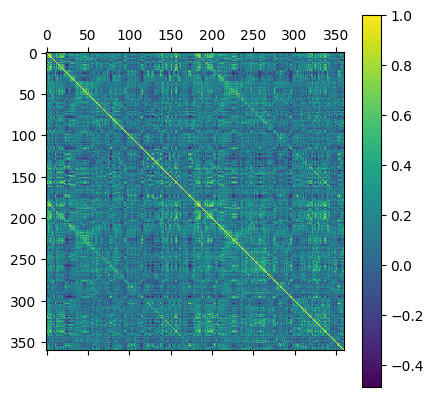

In [96]:
print(data.shape)
plt.matshow(data)
plt.colorbar()

(array([   84.,   827.,  4446., 14692., 21335., 15122.,  5769.,  1774.,
          492.,    79.]),
 array([-0.4893721 , -0.35243257, -0.21549304, -0.0785535 ,  0.05838603,
         0.19532556,  0.3322651 ,  0.46920463,  0.60614416,  0.7430837 ,
         0.88002323]),
 <BarContainer object of 10 artists>)

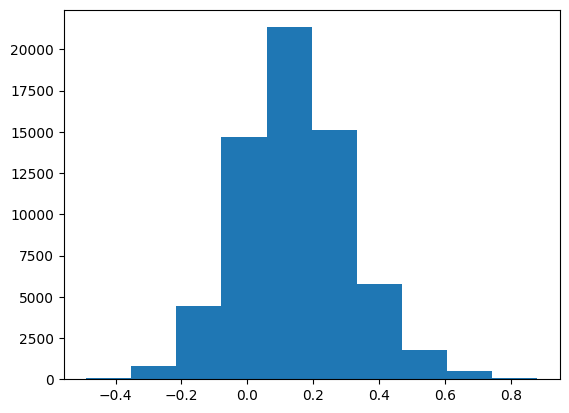

In [107]:
plt.hist(data[np.tril_indices_from(data,k=-1)])

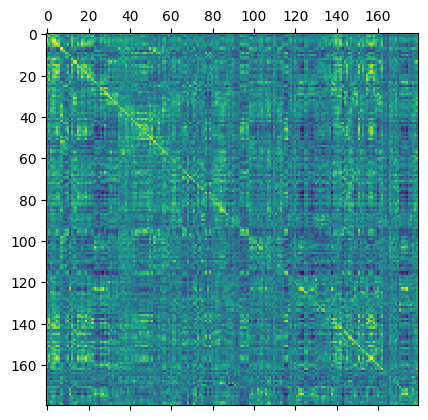

In [97]:
data_RL = data[-180:,:][:,:180]
fc_homoto = np.diag(data_RL)
plt.matshow(data_RL)

In [119]:
atlas_labels['Glasser2016'].remove('???')

ValueError: list.remove(x): x not in list

In [136]:
tmp = fc_homoto.argsort()
labels = np.array(atlas_labels['Glasser2016'])
labels[tmp]

array(['L_55b_ROI', 'L_Ig_ROI', 'L_a47r_ROI', 'L_IFJa_ROI', 'L_pOFC_ROI',
       'L_PoI2_ROI', 'L_p32_ROI', 'L_Pir_ROI', 'L_AAIC_ROI', 'L_13l_ROI',
       'L_EC_ROI', 'L_IP2_ROI', 'L_a10p_ROI', 'L_8C_ROI', 'L_H_ROI',
       'L_FOP2_ROI', 'L_i6-8_ROI', 'L_PEF_ROI', 'L_OFC_ROI', 'L_PreS_ROI',
       'L_PI_ROI', 'L_TE1m_ROI', 'L_PHT_ROI', 'L_24dv_ROI', 'L_STSdp_ROI',
       'L_p32pr_ROI', 'L_10pp_ROI', 'L_FOP3_ROI', 'L_47s_ROI',
       'L_STGa_ROI', 'L_25_ROI', 'L_TE2p_ROI', 'L_TA2_ROI', 'L_s32_ROI',
       'L_43_ROI', 'L_AVI_ROI', 'L_LIPd_ROI', 'L_PSL_ROI', 'L_STSva_ROI',
       'L_p10p_ROI', 'L_47m_ROI', 'L_PHA3_ROI', 'L_PoI1_ROI', 'L_11l_ROI',
       'L_STSda_ROI', 'L_STSvp_ROI', 'L_10r_ROI', 'L_FOP5_ROI',
       'L_SFL_ROI', 'L_a24_ROI', 'L_ProS_ROI', 'L_45_ROI', 'L_OP4_ROI',
       'L_OP1_ROI', 'L_FOP4_ROI', 'L_TE1a_ROI', 'L_IFSa_ROI', 'L_MI_ROI',
       'L_d32_ROI', 'L_p47r_ROI', 'L_MBelt_ROI', 'L_PeEc_ROI',
       'L_PHA2_ROI', 'L_TPOJ2_ROI', 'L_8Av_ROI', 'L_PH_ROI', 'L_p24_ROI',
 

In [137]:
for l,v in zip(labels[tmp],fc_homoto[tmp]):
    print(f'roi:{l:20}, {v:0.4}')

roi:L_55b_ROI           , -0.1425
roi:L_Ig_ROI            , -0.1309
roi:L_a47r_ROI          , -0.01129
roi:L_IFJa_ROI          , 0.05568
roi:L_pOFC_ROI          , 0.1264
roi:L_PoI2_ROI          , 0.137
roi:L_p32_ROI           , 0.1413
roi:L_Pir_ROI           , 0.1474
roi:L_AAIC_ROI          , 0.1623
roi:L_13l_ROI           , 0.1665
roi:L_EC_ROI            , 0.177
roi:L_IP2_ROI           , 0.2068
roi:L_a10p_ROI          , 0.2121
roi:L_8C_ROI            , 0.2191
roi:L_H_ROI             , 0.2366
roi:L_FOP2_ROI          , 0.238
roi:L_i6-8_ROI          , 0.2396
roi:L_PEF_ROI           , 0.2439
roi:L_OFC_ROI           , 0.2441
roi:L_PreS_ROI          , 0.2451
roi:L_PI_ROI            , 0.2585
roi:L_TE1m_ROI          , 0.2592
roi:L_PHT_ROI           , 0.2668
roi:L_24dv_ROI          , 0.2703
roi:L_STSdp_ROI         , 0.2704
roi:L_p32pr_ROI         , 0.2744
roi:L_10pp_ROI          , 0.2784
roi:L_FOP3_ROI          , 0.2806
roi:L_47s_ROI           , 0.2905
roi:L_STGa_ROI          , 0.2919
roi:L_25

(array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 2., 1., 0., 0.,
        1., 1., 1., 1., 5., 0., 3., 3., 2., 4., 0., 2., 2., 3., 1., 2., 1.,
        2., 2., 3., 1., 5., 2., 6., 3., 2., 5., 3., 2., 2., 2., 5., 4., 2.,
        3., 2., 4., 5., 5., 1., 8., 3., 4., 3., 4., 6., 3., 3., 5., 4., 1.,
        4., 3., 2., 0., 1., 0., 1., 0., 1., 1., 1., 1., 2., 4., 1.]),
 array([-0.14250397, -0.13251136, -0.12251875, -0.11252614, -0.10253353,
        -0.09254092, -0.08254831, -0.0725557 , -0.06256309, -0.05257048,
        -0.04257788, -0.03258527, -0.02259266, -0.01260005, -0.00260744,
         0.00738517,  0.01737778,  0.02737039,  0.037363  ,  0.04735561,
         0.05734822,  0.06734083,  0.07733344,  0.08732605,  0.09731866,
         0.10731127,  0.11730388,  0.12729649,  0.1372891 ,  0.14728171,
         0.15727432,  0.16726693,  0.17725954,  0.18725215,  0.19724476,
         0.20723737,  0.21722998,  0.22

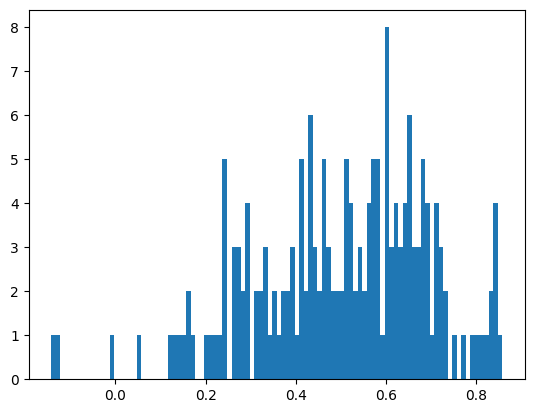

In [108]:
plt.hist(fc_homoto,bins=100)

In [99]:
data_nima = np.loadtxt(f'/home/ali/Downloads/sub-{sub:04}_correlationMatrix.txt')
# data_nima = np.tanh(data_nima)

In [100]:
data_nima.shape
data_RL = data_nima[-180:,:][:,:180]
fc_homoto2 = np.diag(data_RL)

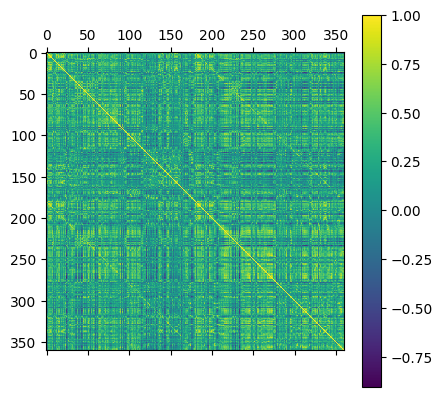

In [101]:
plt.matshow(data_nima)
plt.colorbar()

(array([1.6000e+01, 1.0300e+02, 5.9000e+02, 2.4250e+03, 7.7100e+03,
        1.6151e+04, 1.9977e+04, 1.3232e+04, 3.9860e+03, 4.3000e+02]),
 array([-0.905581 , -0.7234107, -0.5412404, -0.3590701, -0.1768998,
         0.0052705,  0.1874408,  0.3696111,  0.5517814,  0.7339517,
         0.916122 ]),
 <BarContainer object of 10 artists>)

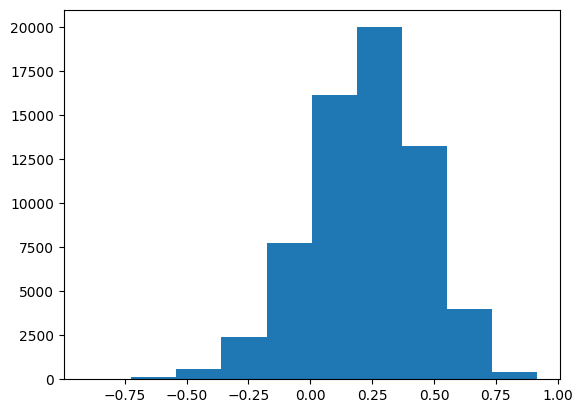

In [106]:
plt.hist(data_nima[np.tril_indices_from(data_nima,k=-1)])

(array([1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 3., 0., 0., 0.,
        1., 2., 0., 2., 3., 2., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1.,
        0., 0., 3., 3., 0., 1., 0., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1.,
        0., 0., 0., 4., 3., 6., 3., 3., 1., 5., 2., 3., 3., 2., 4., 2., 3.,
        3., 5., 3., 3., 5., 2., 5., 6., 3., 3., 4., 3., 3., 7., 2., 1., 3.,
        4., 1., 5., 2., 2., 0., 5., 4., 2., 0., 5., 1., 2., 0., 1.]),
 array([-0.292968 , -0.2808771, -0.2687862, -0.2566953, -0.2446044,
        -0.2325135, -0.2204226, -0.2083317, -0.1962408, -0.1841499,
        -0.172059 , -0.1599681, -0.1478772, -0.1357863, -0.1236954,
        -0.1116045, -0.0995136, -0.0874227, -0.0753318, -0.0632409,
        -0.05115  , -0.0390591, -0.0269682, -0.0148773, -0.0027864,
         0.0093045,  0.0213954,  0.0334863,  0.0455772,  0.0576681,
         0.069759 ,  0.0818499,  0.0939408,  0.1060317,  0.1181226,
         0.1302135,  0.1423044,  0.1543953,  0.1664862,  0.1785771,
      

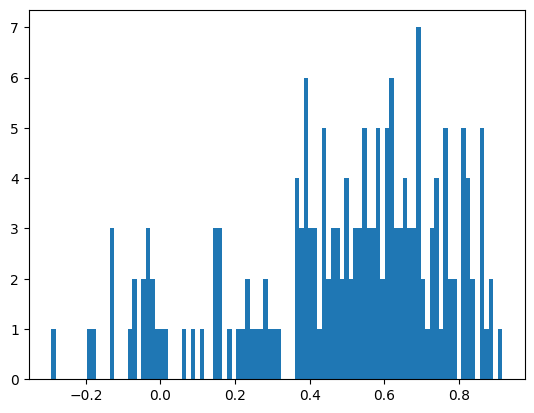

In [127]:
plt.hist(fc_homoto2,bins=100
         )

In [129]:
tmp = fc_homoto2.argsort()
labels[tmp]

array(['L_STSva_ROI', 'L_10pp_ROI', 'L_47s_ROI', 'L_H_ROI', 'L_PSL_ROI',
       'L_TE1m_ROI', 'L_pOFC_ROI', 'L_MBelt_ROI', 'L_TE2a_ROI',
       'L_13l_ROI', 'L_IP2_ROI', 'L_Pir_ROI', 'L_p32pr_ROI', 'L_a47r_ROI',
       'L_Ig_ROI', 'L_43_ROI', 'L_STSvp_ROI', 'L_5m_ROI', 'L_SCEF_ROI',
       'L_i6-8_ROI', 'L_5mv_ROI', 'L_55b_ROI', 'L_25_ROI', 'L_PFt_ROI',
       'L_24dv_ROI', 'L_PoI1_ROI', 'L_8BM_ROI', 'L_PeEc_ROI',
       'L_STSda_ROI', 'L_AAIC_ROI', 'L_s32_ROI', 'L_IPS1_ROI',
       'L_a10p_ROI', 'L_IP1_ROI', 'L_PHT_ROI', 'L_IFJa_ROI', 'L_PGs_ROI',
       'L_PHA2_ROI', 'L_PHA3_ROI', 'L_FOP4_ROI', 'L_STSdp_ROI',
       'L_PEF_ROI', 'L_d32_ROI', 'L_PI_ROI', 'L_STV_ROI', 'L_a32pr_ROI',
       'L_PFcm_ROI', 'L_45_ROI', 'L_7PL_ROI', 'L_FOP2_ROI', 'L_PoI2_ROI',
       'L_24dd_ROI', 'L_PFm_ROI', 'L_EC_ROI', 'L_10v_ROI', 'L_V6_ROI',
       'L_TPOJ2_ROI', 'L_a24_ROI', 'L_LIPd_ROI', 'L_31a_ROI', 'L_OP4_ROI',
       'L_OP1_ROI', 'L_8C_ROI', 'L_FEF_ROI', 'L_FFC_ROI', 'L_TE1a_ROI',
       'L_7Am_RO

In [133]:
for l,v in zip(labels[tmp],fc_homoto2[tmp]):
    print(f'roi:{l:20}, {v:0.4}')

roi:L_STSva_ROI         , -0.293
roi:L_10pp_ROI          , -0.1925
roi:L_47s_ROI           , -0.1836
roi:L_H_ROI             , -0.1284
roi:L_PSL_ROI           , -0.1271
roi:L_TE1m_ROI          , -0.1248
roi:L_pOFC_ROI          , -0.08651
roi:L_MBelt_ROI         , -0.0707
roi:L_TE2a_ROI          , -0.0704
roi:L_13l_ROI           , -0.04825
roi:L_IP2_ROI           , -0.04645
roi:L_Pir_ROI           , -0.03149
roi:L_p32pr_ROI         , -0.02955
roi:L_a47r_ROI          , -0.02759
roi:L_Ig_ROI            , -0.02641
roi:L_43_ROI            , -0.02594
roi:L_STSvp_ROI         , -0.01466
roi:L_5m_ROI            , 0.004278
roi:L_SCEF_ROI          , 0.01937
roi:L_i6-8_ROI          , 0.06679
roi:L_5mv_ROI           , 0.08878
roi:L_55b_ROI           , 0.1067
roi:L_25_ROI            , 0.1435
roi:L_PFt_ROI           , 0.151
roi:L_24dv_ROI          , 0.1542
roi:L_PoI1_ROI          , 0.161
roi:L_8BM_ROI           , 0.162
roi:L_PeEc_ROI          , 0.1627
roi:L_STSda_ROI         , 0.186
roi:L_AAIC_ROI   

(array([ 2.,  8.,  7., 12., 21., 27., 53., 30., 15.,  5.]),
 array([-0.63005025, -0.52430034, -0.41855042, -0.31280051, -0.20705059,
        -0.10130068,  0.00444924,  0.11019915,  0.21594907,  0.32169899,
         0.4274489 ]),
 <BarContainer object of 10 artists>)

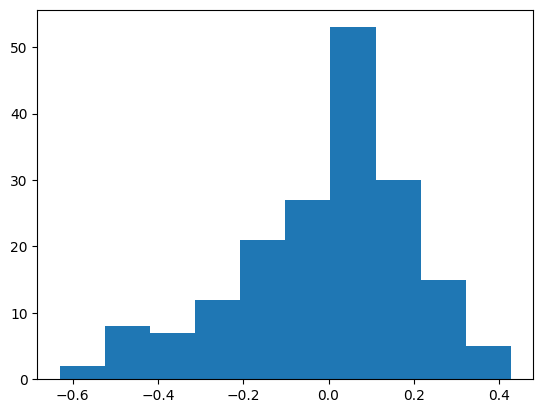

In [103]:
plt.hist(fc_homoto2-fc_homoto)

(array([ 2.,  8.,  7., 12., 21., 27., 53., 30., 15.,  5.]),
 array([-0.63005025, -0.52430034, -0.41855042, -0.31280051, -0.20705059,
        -0.10130068,  0.00444924,  0.11019915,  0.21594907,  0.32169899,
         0.4274489 ]),
 <BarContainer object of 10 artists>)

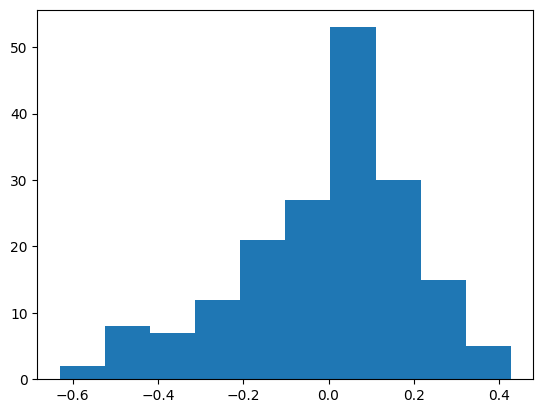

In [104]:
plt.hist(np.diag(data_nima[180:,:][:,:180]-data[180:,:][:,:180]))

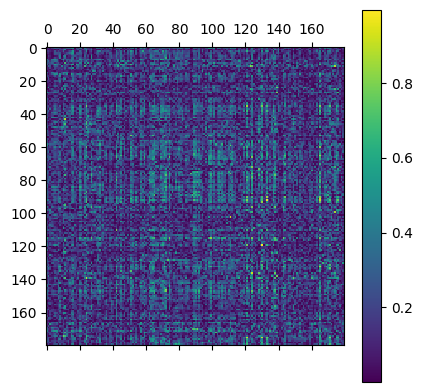

In [105]:
plt.matshow(np.abs(data_nima-data)[180:,:][:,:180])
plt.colorbar()